In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings; warnings.simplefilter('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

In [2]:
books = pd.read_csv('Books.csv', low_memory=False)


In [3]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [4]:
books.shape

(271360, 8)

In [5]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


In [6]:
users = pd.read_csv('Users.csv')

In [7]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


In [9]:
users.shape

(278858, 3)

In [10]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


In [11]:
ratings = pd.read_csv('Ratings.csv')

In [12]:
ratings.head()


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [13]:
ratings.shape

(1149780, 3)

In [14]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [15]:
print(books.columns.tolist())

['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L']


In [16]:
books.columns = books.columns.str.strip()

In [17]:
books.columns= books.columns.str.strip().str.lower().str.replace('-', '_')
users.columns= users.columns.str.strip().str.lower().str.replace('-', '_')
ratings.columns= ratings.columns.str.strip().str.lower().str.replace('-', '_')

In [18]:
pd.set_option('display.max_colwidth', None)

In [19]:
books = books.drop(columns=['image_url_s', 'image_url_m', 'image_url_l'], errors='ignore')

In [20]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 5 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   isbn                 271360 non-null  object
 1   book_title           271360 non-null  object
 2   book_author          271358 non-null  object
 3   year_of_publication  271360 non-null  object
 4   publisher            271358 non-null  object
dtypes: object(5)
memory usage: 10.4+ MB


In [21]:
print(books.isnull().sum())

isbn                   0
book_title             0
book_author            2
year_of_publication    0
publisher              2
dtype: int64


In [22]:
books.loc[(books['book_author'].isnull()),: ]

,isbn,book_title,book_author,year_of_publication,publisher
118033,0751352497,A+ Quiz Masters:01 Earth,NaN,1999,Dorling Kindersley
187689,9627982032,The Credit Suisse Guide to Managing Your Personal Wealth,NaN,1995,Edinburgh Financial Publishing


In [23]:
books.loc[(books['publisher'].isnull()),: ]

,isbn,book_title,book_author,year_of_publication,publisher
128890,193169656X,Tyrant Moon,Elaine Corvidae,2002,NaN
129037,1931696993,Finders Keepers,Linnea Sinclair,2001,NaN


In [24]:
books['year_of_publication'].unique()

array(['2002', '2001', '1991', '1999', '2000', '1993', '1996', '1988',
       '2004', '1998', '1994', '2003', '1997', '1983', '1979', '1995',
       '1982', '1985', '1992', '1986', '1978', '1980', '1952', '1987',
       '1990', '1981', '1989', '1984', '0', '1968', '1961', '1958',
       '1974', '1976', '1971', '1977', '1975', '1965', '1941', '1970',
       '1962', '1973', '1972', '1960', '1966', '1920', '1956', '1959',
       '1953', '1951', '1942', '1963', '1964', '1969', '1954', '1950',
       '1967', '2005', '1957', '1940', '1937', '1955', '1946', '1936',
       '1930', '2011', '1925', '1948', '1943', '1947', '1945', '1923',
       '2020', '1939', '1926', '1938', '2030', '1911', '1904', '1949',
       '1932', '1928', '1929', '1927', '1931', '1914', '2050', '1934',
       '1910', '1933', '1902', '1924', '1921', '1900', '2038', '2026',
       '1944', '1917', '1901', '2010', '1908', '1906', '1935', '1806',
       '2021', '2012', '2006', 'DK Publishing Inc', 'Gallimard', '1909',
       

In [25]:
books[books['year_of_publication'] == 'DK Publishing Inc']

,isbn,book_title,book_author,year_of_publication,publisher
209538,078946697X,"DK Readers: Creating the X-Men, How It All Began (Level 4: Proficient Readers)\"";Michael Teitelbaum""",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.01.THUMBZZZ.jpg
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Books Come to Life (Level 4: Proficient Readers)\"";James Buckley""",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.01.THUMBZZZ.jpg


In [26]:
books[books['year_of_publication'] == 'Gallimard']

,isbn,book_title,book_author,year_of_publication,publisher
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-Marie Gustave Le ClÃ?Â©zio""",2003,Gallimard,http://images.amazon.com/images/P/2070426769.01.THUMBZZZ.jpg


In [27]:
books.loc[221678]

isbn                                                                                                                    0789466953
book_title             DK Readers: Creating the X-Men, How Comic Books Come to Life (Level 4: Proficient Readers)\";James Buckley"
book_author                                                                                                                   2000
year_of_publication                                                                                              DK Publishing Inc
publisher                                                             http://images.amazon.com/images/P/0789466953.01.THUMBZZZ.jpg
Name: 221678, dtype: object

In [28]:
books.loc[209538]

isbn                                                                                                             078946697X
book_title             DK Readers: Creating the X-Men, How It All Began (Level 4: Proficient Readers)\";Michael Teitelbaum"
book_author                                                                                                            2000
year_of_publication                                                                                       DK Publishing Inc
publisher                                                      http://images.amazon.com/images/P/078946697X.01.THUMBZZZ.jpg
Name: 209538, dtype: object

In [29]:
books.loc[220731]

isbn                                                                                 2070426769
book_title             Peuple du ciel, suivi de 'Les Bergers\";Jean-Marie Gustave Le ClÃ?Â©zio"
book_author                                                                                2003
year_of_publication                                                                   Gallimard
publisher                          http://images.amazon.com/images/P/2070426769.01.THUMBZZZ.jpg
Name: 220731, dtype: object

In [30]:
def replace_df_value(df, idx, col_name, val):
    df.loc[idx, col_name] = val
    return df

In [31]:
replace_df_value(books, 209538, 'book_title', 'DK Readers: Creating the X-Men, How It All Began (Level 4: Proficient Readers)')
replace_df_value(books, 209538, 'book_author', 'Michael Teitelbaum')
replace_df_value(books, 209538, 'year_of_publication', 2000)
replace_df_value(books, 209538, 'publisher', 'DK Publishing Inc')

replace_df_value(books, 221678, 'book_title', 'DK Readers: Creating the X-Men, How Comic Books Come to Life (Level 4: Proficient Readers)')
replace_df_value(books, 221678, 'book_author', 'James Buckley')
replace_df_value(books, 221678, 'year_of_publication', 2000)
replace_df_value(books, 221678, 'publisher', 'DK Publishing Inc')

replace_df_value(books, 220731,'book_title', "Peuple du ciel, suivi de 'Les Bergers")
replace_df_value(books, 220731, 'book_author', 'Jean-Marie Gustave Le ClÃ?Â©zio')
replace_df_value(books, 220731, 'year_of_publication', 2003)
replace_df_value(books, 220731, 'publisher', 'Gallimard')

,isbn,book_title,book_author,year_of_publication,publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic of 1918 and the Search for the Virus That Caused It,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company
...,...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,1988,Random House Childrens Pub (Mm)
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books
271357,006008667X,Lily Dale : The True Story of the Town that Talks to the Dead,Christine Wicker,2004,HarperSanFrancisco
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press


In [32]:
books.loc[209538]

isbn                                                                                       078946697X
book_title             DK Readers: Creating the X-Men, How It All Began (Level 4: Proficient Readers)
book_author                                                                        Michael Teitelbaum
year_of_publication                                                                              2000
publisher                                                                           DK Publishing Inc
Name: 209538, dtype: object

In [33]:
books.loc[221678]

isbn                                                                                                   0789466953
book_title             DK Readers: Creating the X-Men, How Comic Books Come to Life (Level 4: Proficient Readers)
book_author                                                                                         James Buckley
year_of_publication                                                                                          2000
publisher                                                                                       DK Publishing Inc
Name: 221678, dtype: object

In [34]:
books.loc[220731]

isbn                                              2070426769
book_title             Peuple du ciel, suivi de 'Les Bergers
book_author                  Jean-Marie Gustave Le ClÃ?Â©zio
year_of_publication                                     2003
publisher                                          Gallimard
Name: 220731, dtype: object

In [35]:
books.loc[(books['publisher'].isnull()),: ]

,isbn,book_title,book_author,year_of_publication,publisher
128890,193169656X,Tyrant Moon,Elaine Corvidae,2002,NaN
129037,1931696993,Finders Keepers,Linnea Sinclair,2001,NaN


In [36]:
books.loc[(books['isbn'] == '193169656X'),'publisher'] = 'No Mention'
books.loc[(books['isbn'] == '1931696993'),'publisher'] = 'No Mention'

In [37]:
df = pd.DataFrame(books)
cols = [4]
df = df[df.columns[cols]]

In [38]:
pd.set_option('display.max_columns', None)  
df.head(5)

,publisher
0,Oxford University Press
1,HarperFlamingo Canada
2,HarperPerennial
3,Farrar Straus Giroux
4,W. W. Norton &amp; Company


In [39]:
books[books['publisher'] == 'No Mention']

,isbn,book_title,book_author,year_of_publication,publisher
128890,193169656X,Tyrant Moon,Elaine Corvidae,2002,No Mention
129037,1931696993,Finders Keepers,Linnea Sinclair,2001,No Mention


In [40]:
print(users.shape)

(278858, 3)


In [41]:
users['age'].unique()

array([ nan,  18.,  17.,  61.,  26.,  14.,  25.,  19.,  46.,  55.,  32.,
        24.,  20.,  34.,  23.,  51.,  31.,  21.,  44.,  30.,  57.,  43.,
        37.,  41.,  54.,  42.,  50.,  39.,  53.,  47.,  36.,  28.,  35.,
        13.,  58.,  49.,  38.,  45.,  62.,  63.,  27.,  33.,  29.,  66.,
        40.,  15.,  60.,   0.,  79.,  22.,  16.,  65.,  59.,  48.,  72.,
        56.,  67.,   1.,  80.,  52.,  69.,  71.,  73.,  78.,   9.,  64.,
       103., 104.,  12.,  74.,  75., 231.,   3.,  76.,  83.,  68., 119.,
        11.,  77.,   2.,  70.,  93.,   8.,   7.,   4.,  81., 114., 230.,
       239.,  10.,   5., 148., 151.,   6., 101., 201.,  96.,  84.,  82.,
        90., 123., 244., 133.,  91., 128.,  94.,  85., 141., 110.,  97.,
       219.,  86., 124.,  92., 175., 172., 209., 212., 237.,  87., 162.,
       100., 156., 136.,  95.,  89., 106.,  99., 108., 210.,  88., 199.,
       147., 168., 132., 159., 186., 152., 102., 116., 200., 115., 226.,
       137., 207., 229., 138., 109., 105., 228., 18

In [42]:
users['age'].fillna((users['age'].mean()), inplace=True)

In [43]:
users['age'].unique()

array([ 34.7514337,  18.       ,  17.       ,  61.       ,  26.       ,
        14.       ,  25.       ,  19.       ,  46.       ,  55.       ,
        32.       ,  24.       ,  20.       ,  34.       ,  23.       ,
        51.       ,  31.       ,  21.       ,  44.       ,  30.       ,
        57.       ,  43.       ,  37.       ,  41.       ,  54.       ,
        42.       ,  50.       ,  39.       ,  53.       ,  47.       ,
        36.       ,  28.       ,  35.       ,  13.       ,  58.       ,
        49.       ,  38.       ,  45.       ,  62.       ,  63.       ,
        27.       ,  33.       ,  29.       ,  66.       ,  40.       ,
        15.       ,  60.       ,   0.       ,  79.       ,  22.       ,
        16.       ,  65.       ,  59.       ,  48.       ,  72.       ,
        56.       ,  67.       ,   1.       ,  80.       ,  52.       ,
        69.       ,  71.       ,  73.       ,  78.       ,   9.       ,
        64.       , 103.       , 104.       ,  12.       ,  74. 

In [44]:
users.loc[(users['age'] > 90) | (users['age'] < 5)] = np.nan

In [45]:
users['age'].fillna((users['age'].mean()), inplace=True)

In [46]:
users['age'].unique()

array([34.7514337 , 18.        , 17.        , 61.        , 26.        ,
       14.        , 25.        , 19.        , 46.        , 55.        ,
       32.        , 24.        , 20.        , 34.        , 23.        ,
       51.        , 31.        , 21.        , 44.        , 30.        ,
       57.        , 43.        , 37.        , 41.        , 54.        ,
       42.        , 50.        , 39.        , 53.        , 47.        ,
       36.        , 28.        , 35.        , 13.        , 58.        ,
       49.        , 38.        , 45.        , 62.        , 63.        ,
       27.        , 33.        , 29.        , 66.        , 40.        ,
       15.        , 60.        , 34.73485224, 79.        , 22.        ,
       16.        , 65.        , 59.        , 48.        , 72.        ,
       56.        , 67.        , 80.        , 52.        , 69.        ,
       71.        , 73.        , 78.        ,  9.        , 64.        ,
       12.        , 74.        , 75.        , 76.        , 83.  

In [47]:
ratings.head()

,user_id,isbn,book_rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [48]:
unique_ratings = ratings[ratings.isbn.isin(books.isbn)]
unique_ratings

,user_id,isbn,book_rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
...,...,...,...
1149774,276704,0876044011,0
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10


In [49]:
print(ratings.shape)
print(unique_ratings.shape)

(1149780, 3)
(1031136, 3)


In [50]:
unique_ratings['book_rating'].unique()

array([ 0,  5,  3,  6,  7,  9,  8, 10,  1,  4,  2])

In [51]:
cb_books = books[['isbn', 'book_title', 'book_author', 'publisher']].copy().dropna()

In [52]:
cb_books['metadata'] = (
    cb_books['book_title'] + " " + 
    cb_books['book_author'] + " " + 
    cb_books['publisher']
)

In [53]:
cb_books_subset = cb_books.iloc[:20000].reset_index(drop=True)

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

In [55]:
tfidf = TfidfVectorizer(stop_words='english')

In [56]:
tfidf_matrix = tfidf.fit_transform(cb_books_subset['metadata'])

In [57]:
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

In [58]:
indices = pd.Series(cb_books_subset.index, index=cb_books_subset['book_title']).drop_duplicates()

In [59]:
def recommend_content_based(title, top_n=5):
    """Recommend the top N similar books based on the input book title."""
    if title not in indices:
        return f"Sorry, '{title}' was not found in the database."

    # Get the index of the book corresponding to the title
    idx = indices[title]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]  # If there are duplicate titles, take the first one

    # Get pairwise similarity scores of all books with that book
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the books based on the similarity scores in descending order
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the top N most similar books (excluding the book itself)
    sim_scores = sim_scores[1 : top_n + 1]
    book_indices = [i[0] for i in sim_scores]

    # Return the top N most similar books along with their similarity scores
    results = cb_books_subset.iloc[book_indices][
        ['book_title', 'book_author', 'publisher']
    ].copy()
    results['similarity_score'] = [round(i[1], 4) for i in sim_scores]

    return results

In [60]:
test_title = cb_books_subset['book_title'].iloc[0]
print(f"Generating content-based recommendations for '{test_title}':")
recommend_content_based(test_title, top_n=5)

Generating content-based recommendations for 'Classical Mythology':


,book_title,book_author,publisher,similarity_score
12657,Sons and Lovers (Oxford World's Classics),D. H. Lawrence,Oxford University Press,0.3321
10701,Symposium (Oxford World's Classics),Plato,Oxford University Press,0.3296
6971,Dracula (Oxford World's Classics),Bram Stoker,Oxford University Press,0.3150
14106,A Tale of Two Cities (Oxford World's Classics),Charles Dickens,Oxford University Press,0.3150
5280,The Mill on the Floss (Oxford World's Classics),George Eliot,Oxford University Press,0.3142


In [61]:
ratings_explicit= unique_ratings[unique_ratings['book_rating'] != 0]   # explicit ratings represented by 1–10
ratings_implicit= unique_ratings[unique_ratings['book_rating'] == 0]   # implicit ratings represented by 0

In [62]:
ratings_explicit.head()

,user_id,isbn,book_rating
1,276726,0155061224,5
3,276729,052165615X,3
4,276729,0521795028,6
8,276744,038550120X,7
16,276747,0060517794,9


In [63]:
print(unique_ratings.shape)
print(ratings_explicit.shape)

(1031136, 3)
(383842, 3)


In [64]:
new_book_df= pd.merge(books, ratings_explicit, on='isbn')
new_book_df.head()

,isbn,book_title,book_author,year_of_publication,publisher,user_id,book_rating
0,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,8,5
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,11676,8
2,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,67544,8
3,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,116866,9
4,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,123629,9


In [65]:
print(new_book_df.shape)

(383842, 7)


In [66]:
new_book_df['book_title'].count()

np.int64(383842)

In [67]:
new_book_df['book_title'].nunique()

135567

In [68]:
top_ten_books= pd.DataFrame(new_book_df.groupby('book_title')['book_rating'].count()
                         .sort_values(ascending=False).head(10))
print('The top ten books as per ratings : ')
top_ten_books

The top ten books as per ratings : 


,book_rating
book_title,
The Lovely Bones: A Novel,707
Wild Animus,581
The Da Vinci Code,494
The Secret Life of Bees,406
The Nanny Diaries: A Novel,393
The Red Tent (Bestselling Backlist),383
Bridget Jones's Diary,377
A Painted House,366
Life of Pi,336


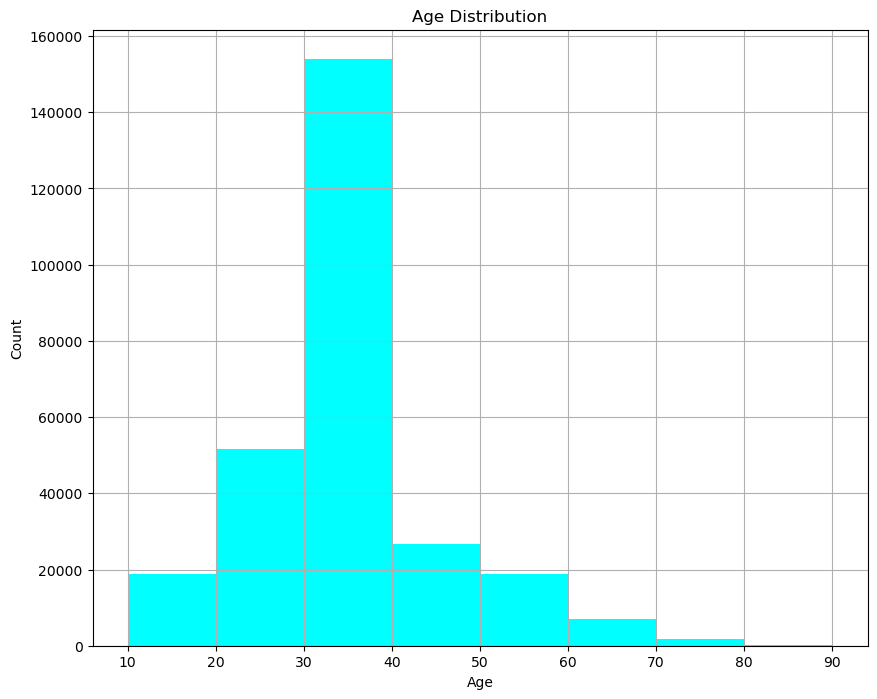

In [69]:
plt.figure(figsize=(10,8))
users.age.hist(bins=[10*i for i in range(1, 10)], color = 'cyan')     
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

<Axes: xlabel='book_rating', ylabel='count'>

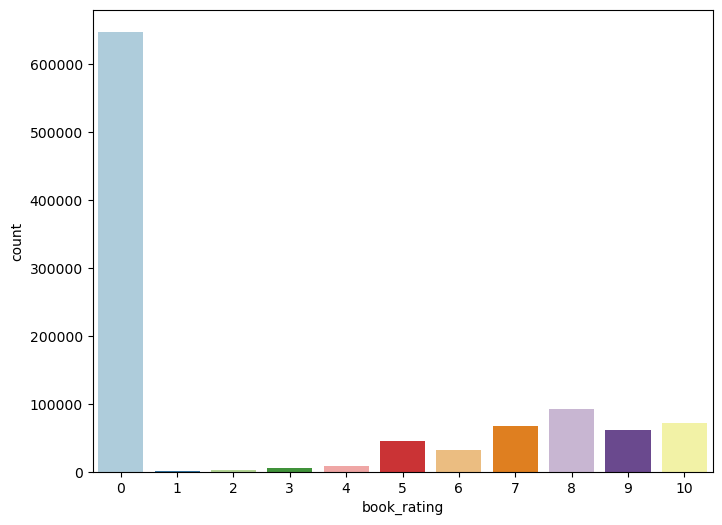

In [70]:
plt.figure(figsize=(8,6))
sns.countplot(x="book_rating",palette = 'Paired',data= unique_ratings)

Text(0.5, 1.0, 'Explicit Ratings')

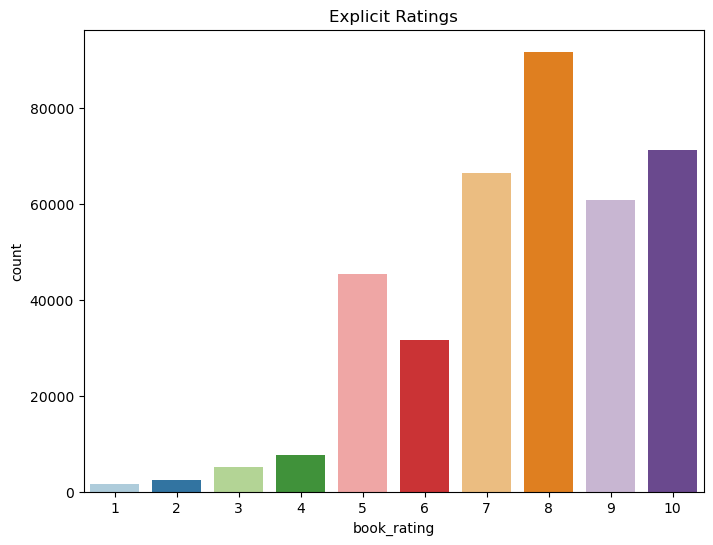

In [71]:
# Explicit Ratings
plt.figure(figsize=(8,6))
rate_data = unique_ratings[unique_ratings['book_rating'] != 0]
sns.countplot(x="book_rating",palette = 'Paired',data=rate_data)
plt.title("Explicit Ratings")

In [72]:
df_merged = ratings.merge(books, on='isbn')

In [73]:
cbf_books = (
    books.dropna(subset=['book_title', 'book_author', 'publisher'])
    .drop_duplicates(subset=['book_title'])
    .head(10000)
    .reset_index(drop=True)  
)

cbf_books['metadata'] = (
    cbf_books['book_title'].astype(str)
    + ' '
    + cbf_books['book_author'].astype(str)
    + ' '
    + cbf_books['publisher'].astype(str)
)

In [74]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(cbf_books['metadata'])
book_indices = pd.Series(
    cbf_books.index, index=cbf_books['book_title']
).drop_duplicates()

In [75]:
df_cbf = df_merged[df_merged['book_title'].isin(cbf_books['book_title'])].copy()
train_cbf, test_cbf = train_test_split(df_cbf, test_size=0.20, random_state=42)

In [76]:
def get_user_profile(user_id, train_data):
    user_ratings = train_data[
        (train_data['user_id'] == user_id) & (train_data['book_rating'] >= 7)
    ]
    if user_ratings.empty:
        return None
    valid_titles = [t for t in user_ratings['book_title'] if t in book_indices]
    if not valid_titles:
        return None
    indices = [book_indices[t] for t in valid_titles]
    return np.asarray(tfidf_matrix[indices].mean(axis=0))

In [77]:
y_true, y_pred = [], []
eval_users = test_cbf['user_id'].unique()[:200]

for u_id in eval_users:
    u_profile = get_user_profile(u_id, train_cbf)
    if u_profile is None:
        continue

    u_test = test_cbf[test_cbf['user_id'] == u_id]
    for _, row in u_test.iterrows():
        b_title = row['book_title']
        actual = row['book_rating']
        if b_title in book_indices:
            b_idx = book_indices[b_title]
            if isinstance(b_idx, pd.Series):
                b_idx = b_idx.iloc[0]
            sim = cosine_similarity(u_profile, tfidf_matrix[b_idx])[0][0]
            pred = sim * 10.0  # Scale similarity to 0-10 rating scale
            y_true.append(actual)
            y_pred.append(pred)

if len(y_true) > 0:
    mse_cbf = mean_squared_error(y_true, y_pred)
    rmse_cbf = np.sqrt(mse_cbf)

    print('==================================================')
    print('📊 Content-Based Filtering (CBF) Evaluation Output')
    print('==================================================')
    print(f'   Mean Squared Error (MSE) : {mse_cbf:.4f}')
    print(f'   Root Mean Squared Error (RMSE): {rmse_cbf:.4f}')
    print('==================================================')

📊 Content-Based Filtering (CBF) Evaluation Output
   Mean Squared Error (MSE) : 15.3279
   Root Mean Squared Error (RMSE): 3.9151
